In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/custom.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# Chapter 6 — Ensemble Learning Techniques
## Lesson 3: Boosting Algorithms (AdaBoost, Gradient Boosting)

**Goal of this lesson:** build a rigorous understanding of *boosting* as *stagewise additive modeling* and learn how to train and tune **AdaBoost** and **Gradient Boosting** models for both classification and regression on real tabular datasets.

We will move back-and-forth between:
- **Theory (loss functions, margins, functional gradient descent)**
- **Implementation (scikit-learn pipelines, evaluation, diagnostics)**
- **Practice (bias–variance reasoning, hyperparameter knobs, failure modes)**

In [2]:
# Core scientific stack
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    AdaBoostClassifier, AdaBoostRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor,
    HistGradientBoostingClassifier, HistGradientBoostingRegressor,
    RandomForestClassifier, RandomForestRegressor
)

from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

np.random.seed(7)

---

## 1) Where boosting fits in ensemble learning

Recall from Lesson 2 (Bagging) that *bagging* reduces variance by averaging many **high-variance** learners trained on bootstrap samples.  
**Boosting** is different: it is primarily a **bias-reduction** strategy that *sequentially* builds an additive model, where each new weak learner focuses on the *current mistakes* of the ensemble.

A useful mental model:

- Bagging: *parallel*, independent base learners → average → variance ↓
- Boosting: *sequential*, dependent base learners → additive correction → bias ↓ (and sometimes variance ↑ if overfit)

### Additive model viewpoint

Boosting constructs a function $F_M(x)$ as a sum of base learners:
$$
F_M(x) = \sum_{m=1}^M \gamma_m h_m(x),
$$
where:
- $h_m(x)$ is the $m$-th weak learner (often a shallow tree),
- $\gamma_m$ is its step size / weight,
- $M$ is the number of boosting rounds (estimators).

The key question becomes: **How do we choose $h_m$ and $\gamma_m$?**  
AdaBoost and Gradient Boosting answer this question differently, but both are instances of *stagewise additive modeling*.

### Two diagrams (high-level flow)

```mermaid
flowchart TD
  A["Start: training set (x_i, y_i)"] --> B["Initialize model F_0(x)"]
  B --> C["For m=1..M"]
  C --> D["Fit weak learner h_m to current training signal"]
  D --> E["Choose weight/step γ_m (and possibly update weights)"]
  E --> F["Update: F_m(x) = F_{m-1}(x) + γ_m h_m(x)"]
  F --> C
  C --> G["Return final ensemble F_M(x)"]
```

```mermaid
flowchart LR
  W["AdaBoost"] -->|reweight samples| S["Emphasize hard examples"]
  G["Gradient Boosting"] -->|fit to negative gradient| R["Emphasize residuals / pseudo-residuals"]
```

In the next sections we formalize both.

In [3]:
from pathlib import Path

def read_csv_rel(path_rel: str) -> pd.DataFrame:
    """
    Read a CSV using the repo-relative paths used in this tutorial.
    Example: "../../../Datasets/Classification/iris.csv"
    """
    p = Path(path_rel)
    if not p.exists():
        raise FileNotFoundError(
            f"Could not find {p}. Make sure you are running this notebook inside the repo, "
            "and that the Datasets/ folder exists with the expected structure."
        )
    return pd.read_csv(p)

def quick_peek(df: pd.DataFrame, n=5):
    display(df.head(n))
    display(df.describe(include="all").T.head(30))

def train_test_basic(X, y, test_size=0.25, stratify=True, random_state=7):
    strat = y if stratify else None
    return train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=strat)

def plot_confusion(y_true, y_pred, labels=None, title="Confusion matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots()
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    if labels is not None:
        ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha="right"); ax.set_yticklabels(labels)
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center")
    plt.show()

def regression_metrics(y_true, y_pred, prefix=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    print(f"{prefix}MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}")
    return mae, rmse, r2

---

## 2) AdaBoost: exponential loss, margins, and reweighting

AdaBoost (Adaptive Boosting) is historically one of the most influential boosting algorithms. It can be derived from multiple perspectives; two particularly useful ones are:

1) **Reweighting view:** iteratively increase weights on misclassified samples.  
2) **Optimization view:** minimize an **exponential loss** using stagewise additive modeling.

We will focus on the optimization view because it produces clean math and generalizes to other boosting methods.

### 2.1 Binary classification setup

Assume binary labels $y_i \in \{-1, +1\}$ and an additive model:
$$
F_M(x) = \sum_{m=1}^M \alpha_m h_m(x),
$$
where each weak classifier $h_m(x) \in \{-1, +1\}$ and $\alpha_m \in \mathbb{R}$.

Define the **margin** for example $i$:
$$
\text{margin}_i = y_i F_M(x_i).
$$
A large positive margin means confident correct prediction; a negative margin implies misclassification.

AdaBoost minimizes the **exponential loss**:
$$
\mathcal{L}(F) = \sum_{i=1}^n \exp\big(-y_i F(x_i)\big).
$$

### 2.2 Stagewise update and reweighting emerges

Suppose we have $F_{m-1}(x)$ and we add $\alpha h(x)$. The loss becomes:
$$
\mathcal{L}(F_{m-1} + \alpha h)
= \sum_{i=1}^n \exp\big(-y_i(F_{m-1}(x_i) + \alpha h(x_i))\big).
$$
Factor the previous term:
$$
= \sum_{i=1}^n \underbrace{\exp\big(-y_i F_{m-1}(x_i)\big)}_{w_i^{(m)}} \exp\big(-\alpha y_i h(x_i)\big).
$$

So the previous ensemble induces **weights**:
$$
w_i^{(m)} = \exp\big(-y_i F_{m-1}(x_i)\big).
$$

Now note that $y_i h(x_i)$ equals $+1$ if correct, and $-1$ if incorrect. Therefore:
- if correct: $\exp(-\alpha y_i h(x_i)) = \exp(-\alpha)$
- if incorrect: $\exp(-\alpha y_i h(x_i)) = \exp(+\alpha)$

Let the weighted classification error of $h$ under weights $w$ be:
$$
\varepsilon = \frac{\sum_{i: y_i \neq h(x_i)} w_i}{\sum_{i=1}^n w_i}.
$$
Then the loss becomes (up to normalization):
$$
\mathcal{L}(\alpha) \propto (1-\varepsilon)\exp(-\alpha) + \varepsilon \exp(+\alpha).
$$
Differentiate and set to zero:
$$
-(1-\varepsilon)\exp(-\alpha) + \varepsilon\exp(\alpha) = 0
\Rightarrow
\exp(2\alpha) = \frac{1-\varepsilon}{\varepsilon}.
$$
Hence:
$$
\boxed{\alpha = \tfrac{1}{2}\ln\Big(\frac{1-\varepsilon}{\varepsilon}\Big).}
$$

### 2.3 Weight update rule

From the definition $w_i^{(m)}=\exp(-y_iF_{m-1}(x_i))$, after adding $\alpha_m h_m$:
$$
w_i^{(m+1)} = w_i^{(m)}\exp\big(-\alpha_m y_i h_m(x_i)\big).
$$

So misclassified samples (where $y_i h_m(x_i)=-1$) get multiplied by $\exp(+\alpha_m)$ and their weight increases.

### 2.4 Multi-class AdaBoost (SAMME / SAMME.R)

For $K>2$ classes, scikit-learn historically supports:
- **SAMME**: a discrete AdaBoost generalization.
- **SAMME.R**: a real-valued variant using class probabilities (behavior varies by version).

We will use **SAMME** explicitly to avoid version ambiguity.

### 2.5 Practical knobs in AdaBoost

Key hyperparameters (scikit-learn):
- `n_estimators` ($M$): number of boosting rounds.
- `learning_rate` (shrinkage): scales $\alpha_m$ and/or step size; smaller values require more estimators.
- `estimator` / `base_estimator`: the weak learner, often a shallow decision tree.

AdaBoost can be surprisingly resistant to overfitting for some problems, but **it can also overfit**—especially with too-deep trees, noisy labels, or too many estimators without shrinkage.

We now turn to Gradient Boosting, which generalizes the idea of fitting *corrections* by explicitly following a loss gradient.

---

## 3) Gradient Boosting: functional gradient descent

Gradient Boosting constructs an additive model by doing gradient descent **in function space**.

We choose:
- a differentiable loss $\ell(y, F(x))$
- a function class for weak learners $h(x)$ (e.g., shallow trees)

and then iterate:
1) compute negative gradient (pseudo-residuals)
2) fit weak learner to those pseudo-residuals
3) take a step of size $\nu$ (learning rate)

### 3.1 General derivation (stagewise)

We want to minimize:
$$
\mathcal{L}(F) = \sum_{i=1}^n \ell\big(y_i, F(x_i)\big).
$$

At stage $m$, we have $F_{m-1}$. We seek $h_m$ and $\gamma_m$ to reduce loss:
$$
F_m(x) = F_{m-1}(x) + \nu \gamma_m h_m(x),
$$
where $\nu \in (0,1]$ is the learning rate (shrinkage).

A canonical algorithm chooses:
- pseudo-residuals:
$$
r_i^{(m)} = -\left.\frac{\partial \ell(y_i, F(x_i))}{\partial F(x_i)}\right|_{F=F_{m-1}}
$$
- fit $h_m$ to $(x_i, r_i^{(m)})$
- choose $\gamma_m$ via a line search:
$$
\gamma_m = \arg\min_{\gamma} \sum_{i=1}^n \ell\big(y_i, F_{m-1}(x_i) + \gamma h_m(x_i)\big)
$$

### 3.2 Important special cases

**Squared error regression**  
Loss: $\ell(y, F) = \tfrac{1}{2}(y - F)^2$  
Derivative:
$$
\frac{\partial \ell}{\partial F} = F - y
\Rightarrow
r_i^{(m)} = y_i - F_{m-1}(x_i),
$$
so pseudo-residuals are literally residuals.

**Binary logistic loss (classification)**  
Let $y \in \{0,1\}$ and probability model $p(x)=\sigma(F(x))$ with $\sigma(z)=1/(1+e^{-z})$.  
Loss:
$$
\ell(y,F)= -y\log\sigma(F) - (1-y)\log(1-\sigma(F)).
$$
Derivative:
$$
\frac{\partial \ell}{\partial F} = \sigma(F) - y
\Rightarrow
r_i^{(m)} = y_i - \sigma(F_{m-1}(x_i)).
$$

### 3.3 Stochastic Gradient Boosting and regularization

Regularization methods:
- **Shrinkage:** smaller learning rate $\nu$, more trees.
- **Subsampling (`subsample` < 1):** stochastic gradient boosting.
- **Tree constraints:** `max_depth`, `min_samples_leaf`, ...
- **Early stopping:** stop when validation score stops improving.

---

## 4) When to prefer AdaBoost vs Gradient Boosting

- **AdaBoost:** often strong on clean-ish classification tasks but can be sensitive to label noise.
- **Gradient Boosting:** more flexible and strong for regression + classification; usually the default baseline.

We will now implement both on multiple datasets.

---

## 5) Hands-on: AdaBoost on a multi-class dataset (Iris)

We start with a small dataset to build intuition, using **decision stumps**.

Expected outcomes:
- strong performance with a modest number of estimators
- confusion matrix reveals which classes remain hard

,sepal_length,sepal_width,petal_length,petal_width,classification
0,5.4,3.7,1.5,0.2,Iris-setosa
1,4.8,3.4,1.6,0.2,Iris-setosa
2,4.8,3.0,1.4,0.1,Iris-setosa
3,4.3,3.0,1.1,0.1,Iris-setosa
4,5.8,4.0,1.2,0.2,Iris-setosa


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sepal_length,150.0,NaN,NaN,NaN,5.843333,0.828066,4.3,5.1,5.8,6.4,7.9
sepal_width,150.0,NaN,NaN,NaN,3.054,0.433594,2.0,2.8,3.0,3.3,4.4
petal_length,150.0,NaN,NaN,NaN,3.758667,1.76442,1.0,1.6,4.35,5.1,6.9
petal_width,150.0,NaN,NaN,NaN,1.198667,0.763161,0.1,0.3,1.3,1.8,2.5
classification,150,3,Iris-setosa,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Accuracy: 0.9736842105263158
F1 (macro): 0.9733333333333333
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        13
Iris-versicolor       1.00      0.92      0.96        13
 Iris-virginica       0.92      1.00      0.96        12

       accuracy                           0.97        38
      macro avg       0.97      0.97      0.97        38
   weighted avg       0.98      0.97      0.97        38



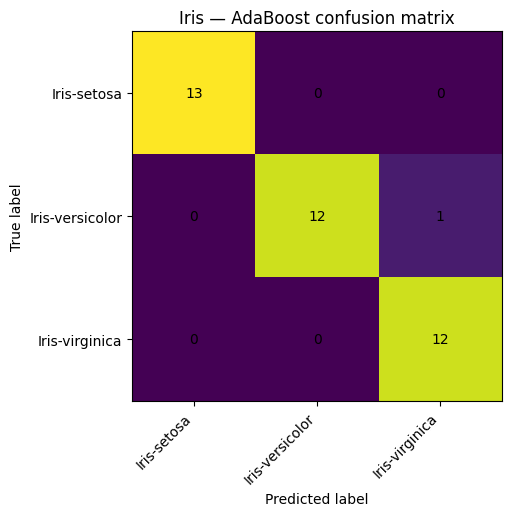

In [4]:
# Dataset 1 (Classification): Iris — multi-class boosting with shallow trees
df_iris = read_csv_rel("../../../Datasets/Classification/iris.csv")
quick_peek(df_iris)

target_col = "classification"
X = df_iris.drop(columns=[target_col])
y = df_iris[target_col]

X_train, X_test, y_train, y_test = train_test_basic(X, y, test_size=0.25, stratify=True)

base = DecisionTreeClassifier(max_depth=1, random_state=7)  # decision stump
ada = AdaBoostClassifier(
    estimator=base,
    n_estimators=300,
    learning_rate=0.6,
    algorithm="SAMME"  # explicit to avoid version ambiguity
)

ada.fit(X_train, y_train)
pred = ada.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("F1 (macro):", f1_score(y_test, pred, average="macro"))
print(classification_report(y_test, pred))
plot_confusion(y_test, pred, labels=sorted(y.unique()), title="Iris — AdaBoost confusion matrix")

---

## 6) Hands-on: AdaBoost on a noisier binary dataset (Diabetes)

We use a slightly deeper base tree and inspect ROC/PR curves to understand thresholding.

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,classification
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non-Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non-Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,NaN,NaN,NaN,3.845052,3.369578,0.0,1.0,3.0,6.0,17.0
Glucose,768.0,NaN,NaN,NaN,120.894531,31.972618,0.0,99.0,117.0,140.25,199.0
BloodPressure,768.0,NaN,NaN,NaN,69.105469,19.355807,0.0,62.0,72.0,80.0,122.0
SkinThickness,768.0,NaN,NaN,NaN,20.536458,15.952218,0.0,0.0,23.0,32.0,99.0
Insulin,768.0,NaN,NaN,NaN,79.799479,115.244002,0.0,0.0,30.5,127.25,846.0
BMI,768.0,NaN,NaN,NaN,31.992578,7.88416,0.0,27.3,32.0,36.6,67.1
DiabetesPedigreeFunction,768.0,NaN,NaN,NaN,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,NaN,NaN,NaN,33.240885,11.760232,21.0,24.0,29.0,41.0,81.0
classification,768,2,Non-Diabetic,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Accuracy: 0.7864583333333334
F1: 0.6611570247933884
ROC AUC: 0.8690746268656716


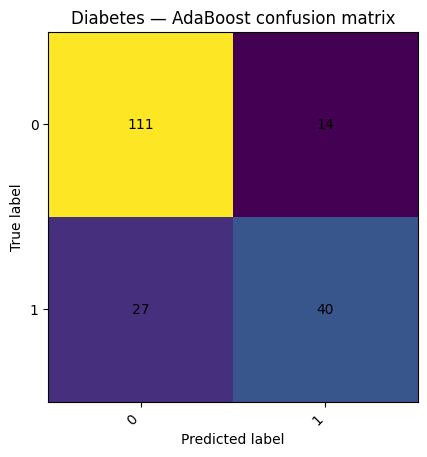

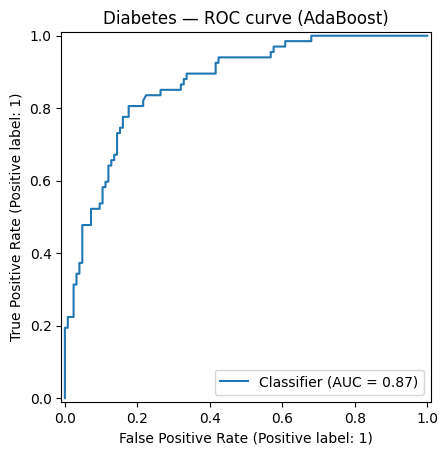

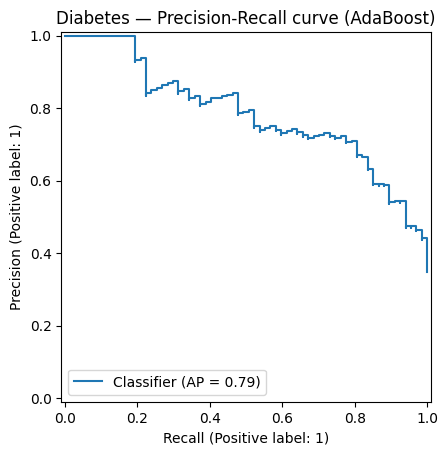

In [5]:
# Dataset 2 (Classification): Diabetes — binary boosting + ROC/PR
df_diab = read_csv_rel("../../../Datasets/Classification/diabetes.csv")
quick_peek(df_diab)

target_col = "classification"
X = df_diab.drop(columns=[target_col])
y = (df_diab[target_col] == "Diabetic").astype(int)

X_train, X_test, y_train, y_test = train_test_basic(X, y, test_size=0.25, stratify=True)

base = DecisionTreeClassifier(max_depth=2, min_samples_leaf=10, random_state=7)
ada = AdaBoostClassifier(
    estimator=base,
    n_estimators=500,
    learning_rate=0.05,
    algorithm="SAMME"
)

ada.fit(X_train, y_train)

proba = ada.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, pred))
print("F1:", f1_score(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, proba))
plot_confusion(y_test, pred, labels=[0,1], title="Diabetes — AdaBoost confusion matrix")

RocCurveDisplay.from_predictions(y_test, proba)
plt.title("Diabetes — ROC curve (AdaBoost)")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, proba)
plt.title("Diabetes — Precision-Recall curve (AdaBoost)")
plt.show()

---

## 7) Hands-on: Gradient Boosting for classification (Wine Quality)

We transform wine quality to a binary label: good (quality ≥ 7) vs not good, then train Gradient Boosting.

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


,count,mean,std,min,25%,50%,75%,max
fixed acidity,4898.0,6.854788,0.843868,3.80000,6.300000,6.80000,7.3000,14.20000
volatile acidity,4898.0,0.278241,0.100795,0.08000,0.210000,0.26000,0.3200,1.10000
citric acid,4898.0,0.334192,0.121020,0.00000,0.270000,0.32000,0.3900,1.66000
residual sugar,4898.0,6.391415,5.072058,0.60000,1.700000,5.20000,9.9000,65.80000
chlorides,4898.0,0.045772,0.021848,0.00900,0.036000,0.04300,0.0500,0.34600
free sulfur dioxide,4898.0,35.308085,17.007137,2.00000,23.000000,34.00000,46.0000,289.00000
total sulfur dioxide,4898.0,138.360657,42.498065,9.00000,108.000000,134.00000,167.0000,440.00000
density,4898.0,0.994027,0.002991,0.98711,0.991723,0.99374,0.9961,1.03898
pH,4898.0,3.188267,0.151001,2.72000,3.090000,3.18000,3.2800,3.82000
sulphates,4898.0,0.489847,0.114126,0.22000,0.410000,0.47000,0.5500,1.08000


Accuracy: 0.84
F1: 0.5441860465116279
ROC AUC: 0.8610259433962264


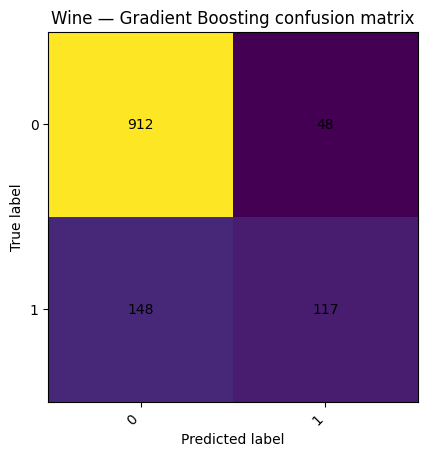

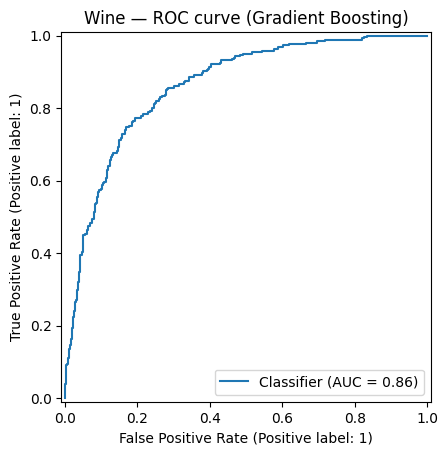

In [6]:
# Dataset 3 (Classification): Wine Quality — transform to binary label and use Gradient Boosting
df_wine = read_csv_rel("../../../Datasets/Classification/Wine_Quality.csv")
quick_peek(df_wine)

# Binary target: "good" if quality >= 7 (common tutorial split)
y = (df_wine["quality"] >= 7).astype(int)
X = df_wine.drop(columns=["quality"])

X_train, X_test, y_train, y_test = train_test_basic(X, y, test_size=0.25, stratify=True)

gb = GradientBoostingClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=2,
    subsample=0.9,
    random_state=7
)
gb.fit(X_train, y_train)

proba = gb.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, pred))
print("F1:", f1_score(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, proba))
plot_confusion(y_test, pred, labels=[0,1], title="Wine — Gradient Boosting confusion matrix")

RocCurveDisplay.from_predictions(y_test, proba)
plt.title("Wine — ROC curve (Gradient Boosting)")
plt.show()

---

## 8) Diagnostics: permutation importance

We compute permutation importance for the wine model with ROC AUC scoring.

Top 15 features by permutation importance (ROC AUC):


alcohol                 0.150612
volatile acidity        0.029057
free sulfur dioxide     0.021397
residual sugar          0.020560
pH                      0.017879
chlorides               0.012789
citric acid             0.010862
density                 0.010777
sulphates               0.008150
total sulfur dioxide    0.005405
fixed acidity           0.005153
dtype: float64

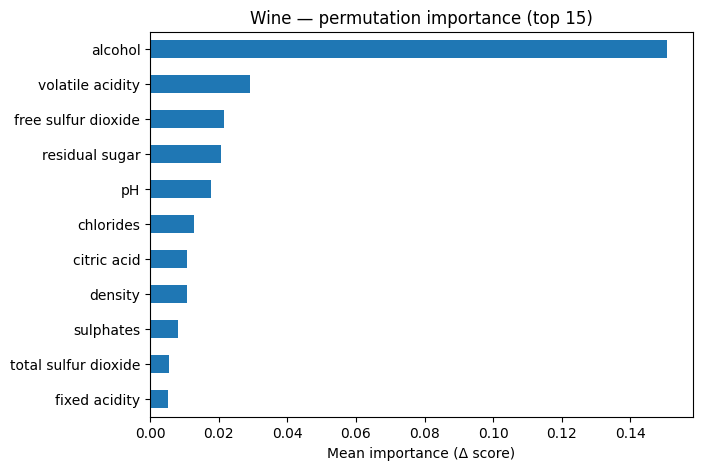

In [7]:
# Feature importance (Permutation Importance) on the Wine model (GradientBoostingClassifier)
# NOTE: permutation importance can be slow on large datasets; Wine is small enough.

result = permutation_importance(gb, X_test, y_test, n_repeats=10, random_state=7, scoring="roc_auc")
imp = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False)

print("Top 15 features by permutation importance (ROC AUC):")
display(imp.head(15))

fig, ax = plt.subplots(figsize=(7, 5))
imp.head(15).iloc[::-1].plot(kind="barh", ax=ax)
ax.set_title("Wine — permutation importance (top 15)")
ax.set_xlabel("Mean importance (Δ score)")
plt.show()

---

## 9) Regression: House Prices with preprocessing pipeline

We use `ColumnTransformer` + `OneHotEncoder` + `GradientBoostingRegressor`, and report MAE/RMSE/R2.

In [8]:
# Dataset 4 (Regression): House Prices — Gradient Boosting Regressor with categorical + numeric
df_house = read_csv_rel("../../../Datasets/Regression/house-prices.csv")
quick_peek(df_house)

y = df_house["Price"]
X = df_house.drop(columns=["Price"])

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("scaler", StandardScaler(with_mean=False))  # safe even if sparse later
        ]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

gbr = GradientBoostingRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.9,
    random_state=7
)

model = Pipeline(steps=[("pre", pre), ("gbr", gbr)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=7)

model.fit(X_train, y_train)
pred = model.predict(X_test)

regression_metrics(y_test, pred, prefix="House — ")

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Home,128.0,NaN,NaN,NaN,64.5,37.094474,1.0,32.75,64.5,96.25,128.0
Price,128.0,NaN,NaN,NaN,130427.34375,26868.770371,69100.0,111325.0,125950.0,148250.0,211200.0
SqFt,128.0,NaN,NaN,NaN,2000.9375,211.572431,1450.0,1880.0,2000.0,2140.0,2590.0
Bedrooms,128.0,NaN,NaN,NaN,3.023438,0.725951,2.0,3.0,3.0,3.0,5.0
Bathrooms,128.0,NaN,NaN,NaN,2.445312,0.514492,2.0,2.0,2.0,3.0,4.0
Offers,128.0,NaN,NaN,NaN,2.578125,1.069324,1.0,2.0,3.0,3.0,6.0
Brick,128,2,No,86,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Neighborhood,128,3,East,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN


House — MAE=10838.9788  RMSE=14177.5059  R2=0.6921


(np.float64(10838.978826231669),
 np.float64(14177.505915765501),
 0.692075556344026)

---

## 10) Regression: Diamonds + model comparison

We compare classic GBR to HistGradientBoostingRegressor for speed/accuracy intuition.

In [9]:
# Dataset 5 (Regression): Diamonds — compare GradientBoostingRegressor vs HistGradientBoostingRegressor
df_dia = read_csv_rel("../../../Datasets/Regression/diamonds.csv")
quick_peek(df_dia)

# Remove ID column if present
if "id" in df_dia.columns:
    df_dia = df_dia.drop(columns=["id"])

y = df_dia["price"]
X = df_dia.drop(columns=["price"])

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("scaler", StandardScaler(with_mean=False))
        ]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

gbr = GradientBoostingRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    random_state=7
)
model_gbr = Pipeline(steps=[("pre", pre), ("gbr", gbr)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=7)

model_gbr.fit(X_train, y_train)
pred_gbr = model_gbr.predict(X_test)
regression_metrics(y_test, pred_gbr, prefix="Diamonds (GBR) — ")

# HistGradientBoosting works best on dense numeric arrays; we will one-hot encode then densify
X_train_enc = pre.fit_transform(X_train)
X_test_enc = pre.transform(X_test)

hgb = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=6,
    max_iter=400,
    random_state=7
)
hgb.fit(X_train_enc.toarray() if hasattr(X_train_enc, "toarray") else X_train_enc, y_train)

pred_hgb = hgb.predict(X_test_enc.toarray() if hasattr(X_test_enc, "toarray") else X_test_enc)
regression_metrics(y_test, pred_hgb, prefix="Diamonds (HistGBR) — ")

,id,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,53940.0,NaN,NaN,NaN,26970.5,15571.281097,1.0,13485.75,26970.5,40455.25,53940.0
carat,53940.0,NaN,NaN,NaN,0.79794,0.474011,0.2,0.4,0.7,1.04,5.01
cut,53940,5,Ideal,21551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
color,53940,7,G,11292,NaN,NaN,NaN,NaN,NaN,NaN,NaN
clarity,53940,8,SI1,13065,NaN,NaN,NaN,NaN,NaN,NaN,NaN
depth,53940.0,NaN,NaN,NaN,61.749405,1.432621,43.0,61.0,61.8,62.5,79.0
table,53940.0,NaN,NaN,NaN,57.457184,2.234491,43.0,56.0,57.0,59.0,95.0
price,53940.0,NaN,NaN,NaN,3932.799722,3989.439738,326.0,950.0,2401.0,5324.25,18823.0
x,53940.0,NaN,NaN,NaN,5.731157,1.121761,0.0,4.71,5.7,6.54,10.74
y,53940.0,NaN,NaN,NaN,5.734526,1.142135,0.0,4.72,5.71,6.54,58.9


Diamonds (GBR) — MAE=343.9316  RMSE=623.1893  R2=0.9756
Diamonds (HistGBR) — MAE=286.3896  RMSE=560.5620  R2=0.9802


(np.float64(286.38962953695983),
 np.float64(560.5620166600547),
 0.9802348453894466)

---

## 11) Early stopping intuition

We track ROC AUC on the test set as a function of boosting stage.

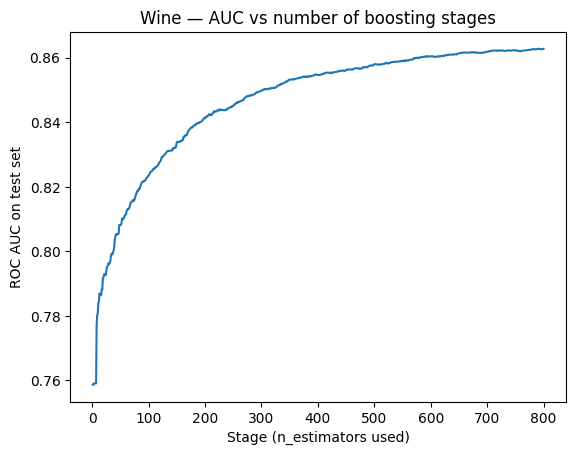

Best stage by test AUC: 800 AUC: 0.8627279874213837


In [10]:
# Recreate the Wine train/test split for this section
df_wine = read_csv_rel("../../../Datasets/Classification/Wine_Quality.csv")
y = (df_wine["quality"] >= 7).astype(int)
X = df_wine.drop(columns=["quality"])
X_train, X_test, y_train, y_test = train_test_basic(X, y, test_size=0.25, stratify=True)

# Early stopping intuition: track deviance over stages for GradientBoostingClassifier on Wine
gb_es = GradientBoostingClassifier(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=2,
    subsample=0.9,
    random_state=7
)
gb_es.fit(X_train, y_train)

# staged_predict_proba yields proba after each stage
test_auc = []
for proba_stage in gb_es.staged_predict_proba(X_test):
    test_auc.append(roc_auc_score(y_test, proba_stage[:, 1]))

fig, ax = plt.subplots()
ax.plot(np.arange(1, len(test_auc) + 1), test_auc)
ax.set_title("Wine — AUC vs number of boosting stages")
ax.set_xlabel("Stage (n_estimators used)")
ax.set_ylabel("ROC AUC on test set")
plt.show()

best_stage = int(np.argmax(test_auc) + 1)
print("Best stage by test AUC:", best_stage, "AUC:", float(np.max(test_auc)))

---

## 12) Hyperparameter tuning: what matters most

The most important knobs:
- `learning_rate` vs `n_estimators`
- tree complexity (`max_depth`, leaf sizes)
- `subsample` for gradient boosting
- early stopping mindset

---

## 13) Summary

- Boosting builds an additive model: $F_M(x)=\sum_{m=1}^M \gamma_m h_m(x)$.
- AdaBoost: exponential loss + reweighting.
- Gradient Boosting: functional gradient descent on a chosen loss.

---

## 14) Exercises

1) Compare AdaBoost base depth on Diabetes.  
2) Tune probability threshold on Wine to maximize F1.  
3) Grid search learning_rate vs n_estimators on House Prices (CV).  
4) Create correlated features and observe permutation importance behavior.

---

## 15) Further reading

- Freund & Schapire — AdaBoost foundations
- Friedman — Gradient Boosting Machine
- Elements of Statistical Learning — Boosting and Additive Trees

---

## Appendix A) Deep dive: margins, generalization, and why boosting can work so well

This appendix adds additional conceptual depth: margin distributions, surrogate losses, and disciplined tuning strategies.

### A.1 Margin distribution
$$
m_i = y_i F(x_i)
$$

### A.2 Exponential vs logistic loss
$$
\mathbf{1}(m \le 0) \le \exp(-m),
\qquad
\log(1+\exp(-m))
$$

### A.3 Practical workflow
A disciplined sequence: metric → baseline → tune (estimators/learning_rate) → tune depth/leaves → re-check leakage/splits → calibrate if needed.